In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('cardekho.csv')
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [3]:
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [5]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [6]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [7]:
df["seats"].value_counts()

seats
5    12910
7     1922
8      311
6      127
4       77
9       55
2        7
0        2
Name: count, dtype: int64

In [8]:
df[df["seats"] == 0]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3217,Honda City,Honda,City,18,40000,Individual,Petrol,Manual,13.00,1493,100.00,0,115000
12619,Nissan Kicks,Nissan,Kicks,2,10000,Individual,Diesel,Manual,19.39,1461,108.49,0,1154000


In [9]:
df.loc[df["seats"] == 0, "seats"] = 5
df[df["seats"] == 0]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price


In [10]:
df[df.duplicated()]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
197,Honda City,Honda,City,8,70000,Individual,Petrol,Manual,16.80,1497,116.30,5,545000
360,Maruti Baleno,Maruti,Baleno,2,5000,Individual,Petrol,Automatic,21.40,1197,83.10,5,686000
1353,Maruti Swift Dzire,Maruti,Swift Dzire,4,50000,Individual,Diesel,Manual,28.40,1248,74.02,5,680000
1429,Maruti Wagon R,Maruti,Wagon R,13,100000,Individual,Petrol,Manual,18.90,1061,67.00,5,150000
1485,Hyundai i20,Hyundai,i20,3,50000,Individual,Petrol,Manual,18.60,1197,81.83,5,625000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15229,Maruti Swift,Maruti,Swift,8,80000,Individual,Diesel,Manual,22.90,1248,74.00,5,350000
15324,Maruti Wagon R,Maruti,Wagon R,6,50000,Individual,CNG,Manual,26.60,998,58.16,5,450000
15367,Tata Tiago,Tata,Tiago,4,30000,Individual,Petrol,Manual,23.84,1199,84.00,5,350000
15378,Hyundai Grand,Hyundai,Grand,6,30000,Individual,Petrol,Manual,18.90,1197,82.00,5,450000


In [11]:
df = df.drop_duplicates(keep="first", ignore_index=True)
df[df.duplicated()]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price


In [12]:
pd.set_option('display.float_format', '{:.4f}'.format)
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15244.0000,15244.0000,15244.0000,15244.0000,15244.0000,15244.0000,15244.0000
mean,6.0411,55639.5823,19.6973,1486.1715,100.6077,5.3268,774701.4481
std,3.0162,51766.2993,4.1693,520.4194,42.9157,0.8065,894676.0819
min,0.0000,100.0000,4.0000,793.0000,38.4000,2.0000,40000.0000
25%,4.0000,30000.0000,17.0000,1197.0000,74.0000,5.0000,385000.0000
50%,6.0000,50000.0000,19.6700,1248.0000,88.5000,5.0000,559000.0000
75%,8.0000,70000.0000,22.7000,1582.0000,117.3000,5.0000,825000.0000
max,29.0000,3800000.0000,33.5400,6592.0000,626.0000,9.0000,39500000.0000


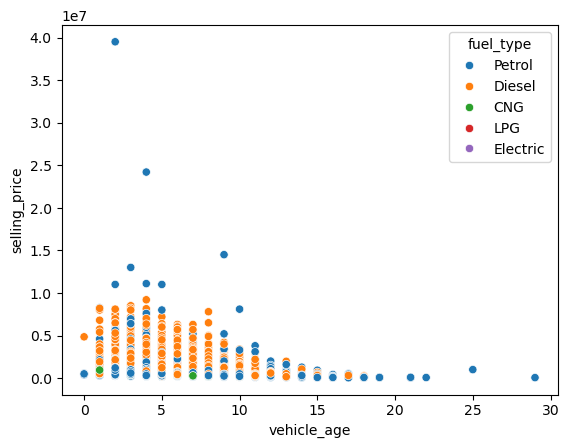

In [13]:
sns.scatterplot(x="vehicle_age", y="selling_price", hue="fuel_type", data=df)
plt.show()

In [14]:
# clean outlier data
df = df[(df["selling_price"] < 15000000)]

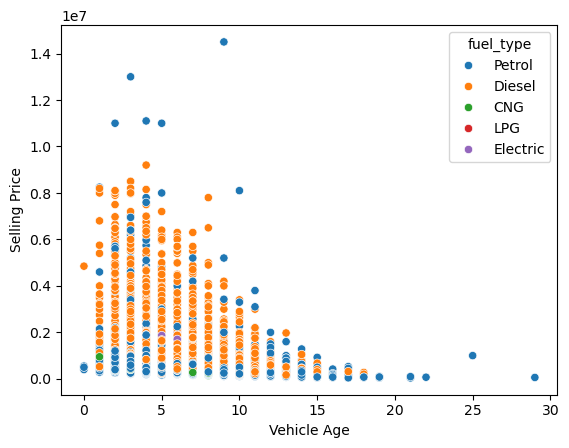

In [15]:
# Aracın yaşı & fiyat ilişkisi
sns.scatterplot(x="vehicle_age", y="selling_price", hue="fuel_type", data=df)
plt.xlabel("Vehicle Age")
plt.ylabel("Selling Price")
plt.show()

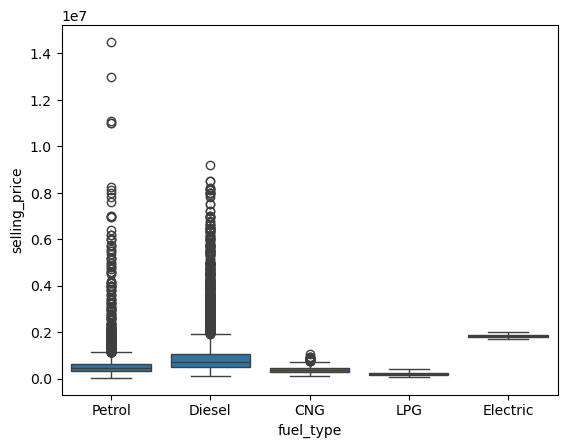

In [16]:
sns.boxplot(data=df, x="fuel_type", y="selling_price")
plt.show()

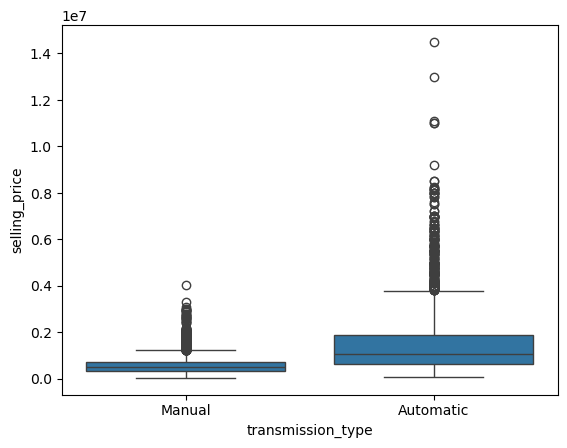

In [17]:
sns.boxplot(data=df, x="transmission_type", y="selling_price")
plt.show()

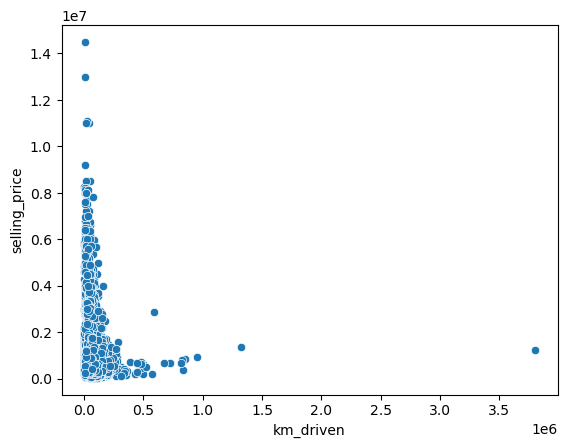

In [18]:
# KM & Fiyat ilişkisi
sns.scatterplot(x="km_driven", y="selling_price", data=df)
plt.show()

In [19]:
# clean outlier data
df = df[(df["km_driven"] < 1000000)]
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15240.0000,15240.0000,15240.0000,15240.0000,15240.0000,15240.0000,15240.0000
mean,6.0414,55317.3224,19.6998,1485.5371,100.5347,5.3269,770556.0285
std,3.0163,40672.4436,4.1666,518.3134,42.5545,0.8063,816201.7843
min,0.0000,100.0000,6.0000,793.0000,38.4000,2.0000,40000.0000
25%,4.0000,30000.0000,17.0000,1197.0000,74.0000,5.0000,385000.0000
50%,6.0000,50000.0000,19.6700,1248.0000,88.5000,5.0000,558500.0000
75%,8.0000,70000.0000,22.7000,1582.0000,117.3000,5.0000,825000.0000
max,29.0000,950000.0000,33.5400,5998.0000,626.0000,9.0000,14500000.0000


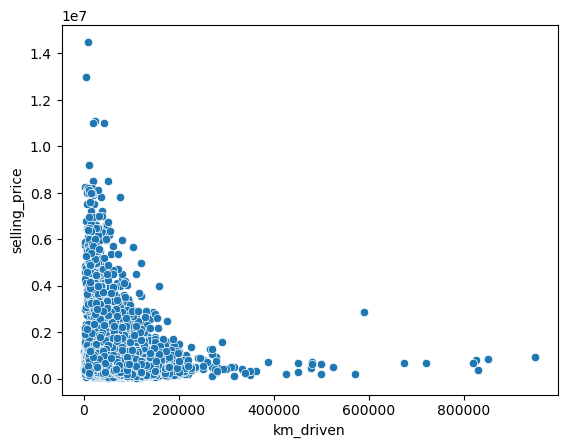

In [20]:
sns.scatterplot(x="km_driven", y="selling_price", data=df)
plt.show()

In [21]:
df.corr(numeric_only=True)

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
vehicle_age,1.0000,0.4235,-0.2582,0.0998,0.0058,0.0313,-0.2591
km_driven,0.4235,1.0000,-0.1248,0.2335,0.0485,0.2326,-0.1095
mileage,-0.2582,-0.1248,1.0000,-0.6323,-0.5323,-0.4430,-0.3186
engine,0.0998,0.2335,-0.6323,1.0000,0.8065,0.5569,0.6118
max_power,0.0058,0.0485,-0.5323,0.8065,1.0000,0.1768,0.7732
seats,0.0313,0.2326,-0.4430,0.5569,0.1768,1.0000,0.1348
selling_price,-0.2591,-0.1095,-0.3186,0.6118,0.7732,0.1348,1.0000


In [22]:
# independent - dependent features
X = df.drop("selling_price", axis=1)
y = df["selling_price"]

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15)

In [24]:
cat_cols = df.select_dtypes("object").columns.to_list()
cat_cols

['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

In [25]:
unique_values = df[cat_cols].nunique()
unique_values

car_name             119
brand                 30
model                118
seller_type            3
fuel_type              5
transmission_type      2
dtype: int64

In [26]:
# seller_type, fuel_type, transmission_type --> OneHotEncoding
# car_name, brand, model --> frequency encoding

onehot_columns = ["seller_type", "fuel_type", "transmission_type"]
freq_columns = ["car_name", "brand", "model"]

In [27]:
X_train["car_name"].value_counts() / len(X_train)

car_name
Hyundai i20          0.0594
Maruti Swift Dzire   0.0555
Maruti Swift         0.0512
Maruti Alto          0.0499
Honda City           0.0491
                      ...  
Lexus NX             0.0001
Porsche Macan        0.0001
Tata Altroz          0.0001
Isuzu MUX            0.0001
Maserati Ghibli      0.0001
Name: count, Length: 116, dtype: float64

In [28]:
for col in freq_columns:
    freq = X_train[col].value_counts() / len(X_train)

    X_train[col + "_freq"] = X_train[col].map(freq)

    X_test[col + "_freq"] = X_test[col].map(freq)

    mean_freq = freq.mean()
    X_test[col + "_freq"] = X_test[col + "_freq"].fillna(mean_freq)

In [29]:
X_train.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,car_name_freq,brand_freq,model_freq
6205,Mahindra XUV500,Mahindra,XUV500,2,18000,Individual,Diesel,Manual,15.1000,2179,152.8700,7,0.0221,0.0668,0.0221
7707,Tata Nexon,Tata,Nexon,4,25000,Individual,Petrol,Manual,17.0000,1198,108.5000,5,0.0053,0.0277,0.0053
5332,Mahindra XUV500,Mahindra,XUV500,4,58500,Dealer,Diesel,Manual,16.0000,2179,140.0000,7,0.0221,0.0668,0.0221
2935,Maruti Eeco,Maruti,Eeco,6,59000,Dealer,Petrol,Manual,15.1000,1196,73.0000,7,0.0076,0.3212,0.0076
6419,Maruti Baleno,Maruti,Baleno,4,32000,Dealer,Petrol,Manual,21.0100,1197,81.8000,5,0.0241,0.3212,0.0241


In [30]:
X_train = X_train.drop(columns = ["car_name", "brand", "model"], axis=1)
X_test = X_test.drop(columns = ["car_name", "brand", "model"], axis=1)

In [31]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [32]:
transformer = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"), onehot_columns)
    ], remainder="passthrough"
)

In [33]:
X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

In [34]:
encoded_cols = transformer.get_feature_names_out()
encoded_cols

array(['onehot__seller_type_Individual',
       'onehot__seller_type_Trustmark Dealer', 'onehot__fuel_type_Diesel',
       'onehot__fuel_type_Electric', 'onehot__fuel_type_LPG',
       'onehot__fuel_type_Petrol', 'onehot__transmission_type_Manual',
       'remainder__vehicle_age', 'remainder__km_driven',
       'remainder__mileage', 'remainder__engine', 'remainder__max_power',
       'remainder__seats', 'remainder__car_name_freq',
       'remainder__brand_freq', 'remainder__model_freq'], dtype=object)

In [35]:
X_train = pd.DataFrame(X_train, columns=encoded_cols)
X_test = pd.DataFrame(X_test, columns=encoded_cols)

In [36]:
X_train.head()

,onehot__seller_type_Individual,onehot__seller_type_Trustmark Dealer,onehot__fuel_type_Diesel,onehot__fuel_type_Electric,onehot__fuel_type_LPG,onehot__fuel_type_Petrol,onehot__transmission_type_Manual,remainder__vehicle_age,remainder__km_driven,remainder__mileage,remainder__engine,remainder__max_power,remainder__seats,remainder__car_name_freq,remainder__brand_freq,remainder__model_freq
0,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,2.0000,18000.0000,15.1000,2179.0000,152.8700,7.0000,0.0221,0.0668,0.0221
1,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,4.0000,25000.0000,17.0000,1198.0000,108.5000,5.0000,0.0053,0.0277,0.0053
2,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,4.0000,58500.0000,16.0000,2179.0000,140.0000,7.0000,0.0221,0.0668,0.0221
3,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,6.0000,59000.0000,15.1000,1196.0000,73.0000,7.0000,0.0076,0.3212,0.0076
4,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,4.0000,32000.0000,21.0100,1197.0000,81.8000,5.0000,0.0241,0.3212,0.0241


In [37]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10668 entries, 0 to 10667
Data columns (total 16 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   onehot__seller_type_Individual        10668 non-null  float64
 1   onehot__seller_type_Trustmark Dealer  10668 non-null  float64
 2   onehot__fuel_type_Diesel              10668 non-null  float64
 3   onehot__fuel_type_Electric            10668 non-null  float64
 4   onehot__fuel_type_LPG                 10668 non-null  float64
 5   onehot__fuel_type_Petrol              10668 non-null  float64
 6   onehot__transmission_type_Manual      10668 non-null  float64
 7   remainder__vehicle_age                10668 non-null  float64
 8   remainder__km_driven                  10668 non-null  float64
 9   remainder__mileage                    10668 non-null  float64
 10  remainder__engine                     10668 non-null  float64
 11  remainder__max_

In [38]:
# model
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV

In [39]:
model = AdaBoostRegressor()

In [40]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [41]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 423689.6662970418
MSE: 258773952978.89764
R2 Score: 0.6052856249486689


In [42]:
params = {
    "n_estimators": [50,80,100,120],
    "learning_rate": [0.001, 0.01, 0.1, 1.0, 2.0],
    "loss": ["linear", "square", "exponential"]
}

In [46]:
rcv = RandomizedSearchCV(estimator=AdaBoostRegressor(), param_distributions=params, scoring="r2", n_jobs=-1)

In [47]:
rcv.fit(X_train, y_train)

RandomizedSearchCV(estimator=AdaBoostRegressor(), n_jobs=-1,
                   param_distributions={'learning_rate': [0.001, 0.01, 0.1, 1.0,
                                                          2.0],
                                        'loss': ['linear', 'square',
                                                 'exponential'],
                                        'n_estimators': [50, 80, 100, 120]},
                   scoring='r2')

In [48]:
rcv.best_params_

{'n_estimators': 50, 'loss': 'exponential', 'learning_rate': 0.1}

In [49]:
y_pred = rcv.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 224592.3868938575
MSE: 129907159652.06857
R2 Score: 0.8018493641014125
